# Label behavior playground

Visual sanity check for what "gradient descent on the prior's true surface"
actually does to a handful of random points — not tied to
`exploit_search`/`explore_search`'s own incumbent-seeding or multistart
machinery (see `notebooks/exploit_search_restart_trajectories.ipynb` for
that), just the plain mechanism underneath both of them: start somewhere,
nudge downhill for a fixed number of steps, see where you land.

This is not a search for each instance's true optimum — with a modest
number of GD steps, each point typically ends up somewhere *locally*
better, not at the global best. That's deliberate: the point is to build
intuition for what an oracle-search-style correction actually looks like
on a real BNN draw, for `docs/log/` discussion around M5's exploit/explore
label quality.

In [1]:
import torch
import matplotlib.pyplot as plt

from anytimeacquisition.priors.bnn import BNNPrior

torch.manual_seed(0)

## The two functions

`refine_random_points` starts `n_points` random locations per prior
instance and runs plain gradient descent on each, directly against the
prior's own true (noise-free) surface — the same "points per instance"
batching trick `exploit_search`/`explore_search` use, without their
incumbent-seeding or multistart-restart logic.

`plot_refinement` draws one instance's true surface with every point's
start position and an arrow to where gradient descent moved it. Works for
`prior.d` in `{1, 2}`.

In [2]:
def refine_random_points(prior, n_points, n_steps=50, lr=0.05, seed=None):
    """Start `n_points` random locations per prior instance and run plain
    gradient descent on each, directly against the prior's own true (noise-
    free) surface. Not a search for the optimum: with a modest `n_steps`,
    each point typically ends up somewhere locally better, not at the
    instance's true best point.

    Parameters
    ----------
    prior : BNNPrior
        An already-`reset()` BNN instance (or batch of instances).
    n_points : int
        How many independent random starting points per instance.
    n_steps : int
        Number of gradient descent steps to take.
    lr : float
        Adam learning rate.
    seed : int, optional
        Set for reproducible starting points.

    Returns
    -------
    x_start, x_end : Tensor [B, n_points, x_dim]
        Where each point started and where it ended up.
    y_start, y_end : Tensor [B, n_points]
        The true (noise-free) function value at those positions.
    """
    if seed is not None:
        torch.manual_seed(seed)
    B, x_dim = prior.B, prior.d

    x = torch.rand(B, n_points, x_dim, requires_grad=True)
    with torch.no_grad():
        y_start = prior.evaluate(x, noise=False)
    x_start = x.detach().clone()

    opt = torch.optim.Adam([x], lr=lr)
    for _ in range(n_steps):
        y = prior.evaluate(x, noise=False)
        opt.zero_grad()
        y.sum().backward()
        opt.step()
        with torch.no_grad():
            x.clamp_(0.0, 1.0)

    with torch.no_grad():
        y_end = prior.evaluate(x, noise=False)
    x_end = x.detach().clone()

    return x_start, x_end, y_start, y_end

In [3]:
def plot_refinement(prior, x_start, x_end, y_start, y_end, instance_idx=0, grid_res=200, ax=None):
    """Plot one instance's true surface with every point's start position
    and an arrow to where gradient descent moved it. Works for `prior.d`
    in `{1, 2}` -- pass any other dimensionality and there's nothing
    sensible to draw.

    Parameters
    ----------
    prior : BNNPrior
        The same instance(s) `refine_random_points` was run against.
    x_start, x_end, y_start, y_end : Tensor
        `refine_random_points`'s own return values.
    instance_idx : int
        Which batch element to plot -- change this to look at a different
        instance from the same batch.
    grid_res : int
        Resolution of the true-surface grid/curve.
    ax : matplotlib Axes, optional
        Draw into this axes instead of creating a new figure.

    Returns
    -------
    The matplotlib Axes drawn into.
    """
    assert prior.d in (1, 2), f"only 1D/2D surfaces are plottable, got prior.d={prior.d}"
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    lin = torch.linspace(0.0, 1.0, grid_res)
    xs, xe = x_start[instance_idx], x_end[instance_idx]  # [n_points, x_dim]
    ys, ye = y_start[instance_idx], y_end[instance_idx]  # [n_points]

    if prior.d == 1:
        grid = lin.view(1, -1, 1).expand(prior.B, -1, -1)
        with torch.no_grad():
            grid_y = prior.evaluate(grid, noise=False)[instance_idx]
        ax.plot(lin.numpy(), grid_y.numpy(), color="black", linewidth=1.5, label="true f(x)")
        ax.scatter(xs[:, 0], ys, color="tab:blue", zorder=5, label="start")
        ax.scatter(xe[:, 0], ye, color="tab:red", zorder=5, label="end")
        for i in range(xs.shape[0]):
            ax.annotate(
                "", xy=(xe[i, 0].item(), ye[i].item()), xytext=(xs[i, 0].item(), ys[i].item()),
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.7),
            )
        ax.set_xlabel("x")
        ax.set_ylabel("y (lower is better)")
    else:
        grid = torch.stack(torch.meshgrid(lin, lin, indexing="ij"), dim=-1).reshape(1, -1, 2).expand(prior.B, -1, -1)
        with torch.no_grad():
            grid_y = prior.evaluate(grid, noise=False)[instance_idx].reshape(grid_res, grid_res)
        im = ax.contourf(lin.numpy(), lin.numpy(), grid_y.numpy().T, levels=30, cmap="viridis")
        ax.figure.colorbar(im, ax=ax, pad=0.02).set_label("true y (lower is better)")
        ax.scatter(xs[:, 0], xs[:, 1], color="white", edgecolor="black", zorder=5, label="start")
        ax.scatter(xe[:, 0], xe[:, 1], color="red", edgecolor="black", zorder=5, label="end")
        for i in range(xs.shape[0]):
            ax.annotate(
                "", xy=(xe[i, 0].item(), xe[i, 1].item()), xytext=(xs[i, 0].item(), xs[i, 1].item()),
                arrowprops=dict(arrowstyle="->", color="white", alpha=0.9),
            )
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    n_improved = (ye <= ys + 1e-6).sum().item()
    ax.set_title(f"instance {instance_idx}: {xs.shape[0]} points, {n_improved} improved or unchanged")
    ax.legend(loc="best", fontsize=8)
    return ax

## 1D example

`batch_size=4` gives 4 independently drawn true functions. `instance_idx`
in the plotting cell below picks which one to look at — change it and
re-run just that cell, no need to recompute `refine_random_points`.

In [4]:
prior_1d = BNNPrior(batch_size=4, x_dim=1, seed=0)
prior_1d.reset()
x_start_1d, x_end_1d, y_start_1d, y_end_1d = refine_random_points(prior_1d, n_points=8, n_steps=40, seed=1)

improvement_1d = y_start_1d - y_end_1d  # positive = got better (lower y)
improved_frac = (improvement_1d >= -1e-6).float().mean().item()
print(f"{improved_frac:.1%} of points ended up better or unchanged "
      f"(mean y: {y_start_1d.mean():.4f} -> {y_end_1d.mean():.4f})")
print(f"overall improvement from updating the label (y_start - y_end) over all "
      f"{improvement_1d.numel()} points: mean={improvement_1d.mean():.4f}  total={improvement_1d.sum():.4f}")

100.0% of points ended up better or unchanged (mean y: 0.5560 -> 0.3441)
overall improvement from updating the label (y_start - y_end) over all 32 points: mean=0.2119  total=6.7795


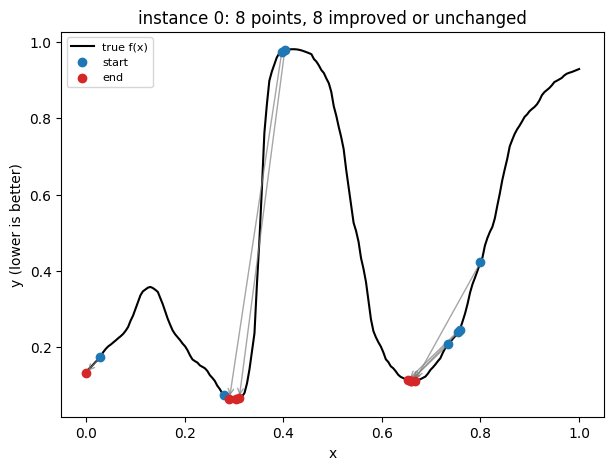

In [5]:
instance_idx = 0  # <-- change this (0..3) to look at a different instance
plot_refinement(prior_1d, x_start_1d, x_end_1d, y_start_1d, y_end_1d, instance_idx=instance_idx)
plt.show()

## 2D example

Same mechanism, `x_dim=2` — the true surface is now a filled contour
instead of a curve, and arrows show 2D movement in `x`-space rather than
being tied to the (now-implicit) `y` axis.

In [6]:
prior_2d = BNNPrior(batch_size=4, x_dim=2, seed=0)
prior_2d.reset()
x_start_2d, x_end_2d, y_start_2d, y_end_2d = refine_random_points(prior_2d, n_points=8, n_steps=5, seed=1)

improvement_2d = y_start_2d - y_end_2d  # positive = got better (lower y)
improved_frac = (improvement_2d >= -1e-6).float().mean().item()
print(f"{improved_frac:.1%} of points ended up better or unchanged "
      f"(mean y: {y_start_2d.mean():.4f} -> {y_end_2d.mean():.4f})")
print(f"overall improvement from updating the label (y_start - y_end) over all "
      f"{improvement_2d.numel()} points: mean={improvement_2d.mean():.4f}  total={improvement_2d.sum():.4f}")

100.0% of points ended up better or unchanged (mean y: 0.4722 -> 0.3827)
overall improvement from updating the label (y_start - y_end) over all 32 points: mean=0.0895  total=2.8644


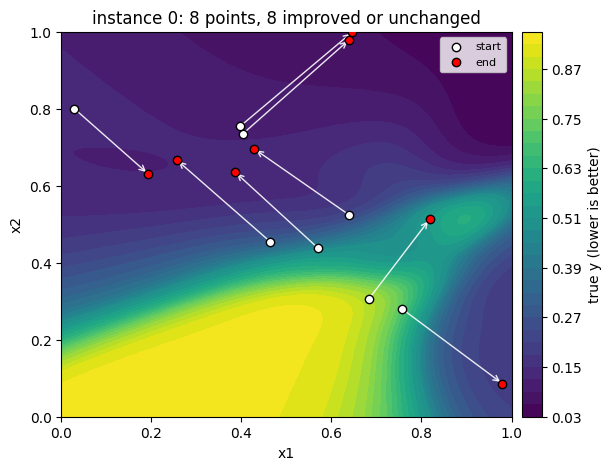

In [7]:
instance_idx = 0  # <-- change this (0..3) to look at a different instance
plot_refinement(prior_2d, x_start_2d, x_end_2d, y_start_2d, y_end_2d, instance_idx=instance_idx)
plt.show()